In [7]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, roc_curve
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, KFold
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from RegressionModels.xgboost_reg import best_estimator

In [8]:
csv_filename_train = "../CleanData/full_train_05_09.csv"
df_train = pd.read_csv(csv_filename_train)
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72967 entries, 0 to 72966
Data columns (total 88 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   site                  72967 non-null  object 
 1   daynight              72967 non-null  int64  
 2   attendance            72967 non-null  int64  
 3   temp                  72967 non-null  float64
 4   windspeed             72967 non-null  float64
 5   Home_Away             72967 non-null  int64  
 6   left_on_base          72967 non-null  int64  
 7   bat_doubles           72967 non-null  int64  
 8   bat_triples           72967 non-null  int64  
 9   bat_home_runs         72967 non-null  int64  
 10  bat_stolen_bases      72967 non-null  int64  
 11  passed_balls_allowed  72967 non-null  int64  
 12  errors_committed      72967 non-null  int64  
 13  stolen_bases          72967 non-null  int64  
 14  yearID                72967 non-null  int64  
 15  salary             

In [9]:
csv_filename_train = "../CleanData/full_test_05_09.csv"
df_test = pd.read_csv(csv_filename_train)
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18242 entries, 0 to 18241
Data columns (total 88 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   site                  18242 non-null  object 
 1   daynight              18242 non-null  int64  
 2   attendance            18242 non-null  int64  
 3   temp                  18242 non-null  float64
 4   windspeed             18242 non-null  float64
 5   Home_Away             18242 non-null  int64  
 6   left_on_base          18242 non-null  int64  
 7   bat_doubles           18242 non-null  int64  
 8   bat_triples           18242 non-null  int64  
 9   bat_home_runs         18242 non-null  int64  
 10  bat_stolen_bases      18242 non-null  int64  
 11  passed_balls_allowed  18242 non-null  int64  
 12  errors_committed      18242 non-null  int64  
 13  stolen_bases          18242 non-null  int64  
 14  yearID                18242 non-null  int64  
 15  salary             

In [10]:
df_test = df_test.drop(columns=['site'])
df_train = df_train.drop(columns=['site'])

y_train = df_train['score_diff']
df_train = df_train.drop(columns=['score_diff'])
y_test = df_test['score_diff']
df_test = df_test.drop(columns=['score_diff'])

In [11]:
# transform winner 1/0 depending on score_diff
check_class = lambda x: 1 if x > 0 else 0
y_train_class = pd.Series(data=[check_class(x) for x in y_train])
y_test_class = pd.Series(data=[check_class(x) for x in y_test])

In [15]:
#Hyperparameter Tuning
random_state = 123
xg_classifier = XGBClassifier(random_state=random_state, eval_metric='logloss')
cv = KFold(n_splits=5, shuffle=True, random_state=random_state)

param_dist = {
    'n_estimators': np.arange(100, 301, 5),
    'max_depth': np.arange(1, 31, 1),
    'learning_rate': [0.1, 0.15, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'alpha': [0, 0.1, 0.2, 0.3],
    'lambda': [0.1, 1, 2]
}

random_search = RandomizedSearchCV(
    estimator=xg_classifier,
    param_distributions=param_dist,
    n_iter=50, 
    cv=cv,
    scoring='accuracy',
    random_state=random_state,
    n_jobs=-1,
    error_score='raise'
)

# Fit the random search
random_search.fit(df_train, y_train_class)

# Get the best parameters
best_params = random_search.best_params_
best_estimator = random_search.best_estimator_
print("\nBest Parameters Found:")
print(best_params)


Best Parameters Found:
{'subsample': 0.6, 'n_estimators': np.int64(220), 'max_depth': np.int64(3), 'learning_rate': 0.15, 'lambda': 1, 'colsample_bytree': 0.6, 'alpha': 0.2}


In [16]:
#Cross Validation with tuned params
# best_params = {'subsample': 0.6, 'n_estimators': np.int64(220), 'max_depth': np.int64(3), 'learning_rate': 0.15, 'lambda': 1, 'colsample_bytree': 0.6, 'alpha': 0.2}

# accuracy
accuracy_scores = cross_val_score(best_estimator, df_train, y_train_class, cv=5, scoring='accuracy')
print("Avg Accuracy:", np.mean(accuracy_scores), "STD", np.std(accuracy_scores))

# recall
recall_scores = cross_val_score(best_estimator, df_train, y_train_class, cv=5, scoring='recall')
print("Avg Recall:", np.mean(recall_scores), "STD", np.std(recall_scores))

# precision
precision_scores = cross_val_score(best_estimator, df_train, y_train_class, cv=5, scoring='precision')
print("Avg Precision:", np.mean(precision_scores), "STD", np.std(precision_scores))

# f1
f1_scores = cross_val_score(best_estimator, df_train, y_train_class, cv=5, scoring='f1')
print("Avg F1:", np.mean(f1_scores), "STD", np.std(f1_scores))


Avg Accuracy: 0.7007825309227943 STD 0.0020119770730393166
Avg Recall: 0.6985007768029773 STD 0.005558834698204716
Avg Precision: 0.7025226478813115 STD 0.0018137879413031308
Avg F1: 0.7004934445972479 STD 0.002900761174422593


In [17]:
#Model Evaluation
y_pred = best_estimator.predict(df_test)

accuracy = accuracy_score(y_test_class, y_pred)
f1 = f1_score(y_test_class, y_pred)
precision = precision_score(y_test_class, y_pred)
recall = recall_score(y_test_class, y_pred)
print(f"Accuracy score: {accuracy:.4f}", )
print(f"Precision:      {precision:.4f}")
print(f"Recall:         {recall:.4f}")
print(f"F1 Score:       {f1:.4f}")

Accuracy score: 0.7032
Precision:      0.7000
Recall:         0.7020
F1 Score:       0.7010


AUC-ROC Score: 0.7730


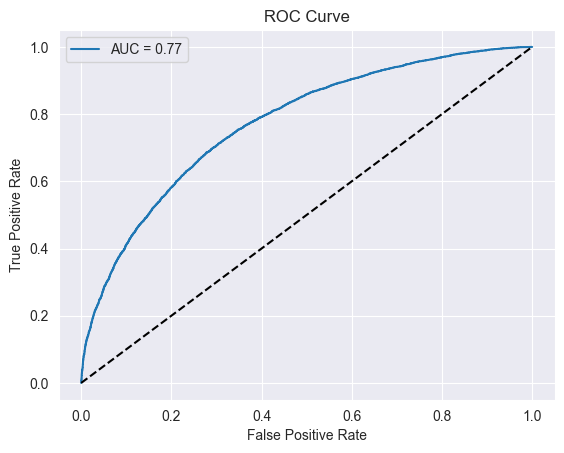

In [18]:
# ROC Curve
y_probs = best_estimator.predict_proba(df_test)[:, 1]
auc_score = roc_auc_score(y_test_class, y_probs)
print(f"AUC-ROC Score: {auc_score:.4f}")

# plot
fpr, tpr, _ = roc_curve(y_test_class, y_probs)
plt.plot(fpr, tpr, label=f'AUC = {auc_score:.2f}')
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
#Feature Importance
importances = best_estimator.feature_importances_

feature_names = df_train.columns.tolist()

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance_df.head(15)

,Feature,Importance
8,bat_home_runs,0.162935
6,bat_doubles,0.093555
9,bat_stolen_bases,0.066497
12,stolen_bases,0.062419
11,errors_committed,0.059983
7,bat_triples,0.056711
4,Home_Away,0.037412
10,passed_balls_allowed,0.020458
5,left_on_base,0.014849
34,DEN02,0.014823


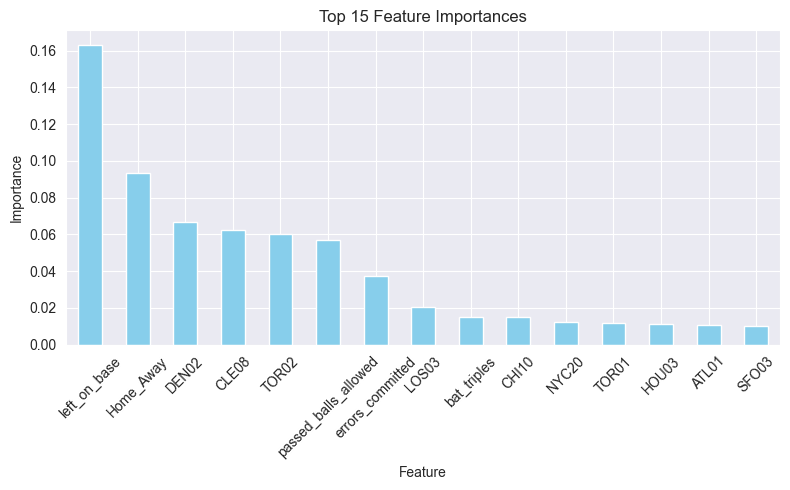

In [21]:
importances = pd.Series(best_estimator.feature_importances_, index=feature_importance_df['Feature'])

top_15 = importances.sort_values(ascending=False).head(15)

# Plot
top_15.plot(kind='bar', figsize=(8, 5), color='skyblue')
plt.title('Top 15 Feature Importances')
plt.ylabel('Importance')
plt.xlabel('Feature')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()